In [46]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
from math import comb 



In [ ]:
# Configuración reproducible
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Parámetros del problema
MIN_HEADWAY = 4.0          # La separación mínima permitida entre aviones, medida en minutos de tiempo de vuelo.
TARGET_HEADWAY = 5.0       # Valor objetivo de separación: los aviones intentan mantener 5 minutos de distancia como buffer de seguridad adicional, si están muy cerca, el avión de atrás baja la velocidad hasta aumentar ese gap a 5.
RADAR_NM = 100.0           # Distancia en millas náuticas (mn) a la que los aviones entran en el radar de Aeroparque (AEP). Cada avión aparece “en la simulación” en este punto inicial.
BACKTRACK_SPEED_KTS = 200.0  # Si un avión no puede mantener la separación (porque debería ir más lento que el mínimo permitido), se sale de la fila y vuela hacia atrás a 200 nudos hasta encontrar un hueco (o salirse del radar a Montevideo, según el caso). Es la velocidad que se usa en ese modo “backtrack”.
NM_PER_MIN_FROM_KTS = 1.0 / 60.0  # conversión nudos -> mn/min

In [3]:
def speed_bounds_for_distance(distance_nm: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) permitidos según la tabla del enunciado."""
    if distance_nm > 100.0:
        return 300.0, 500.0
    elif distance_nm > 50.0:
        return 250.0, 300.0   # 100..50
    elif distance_nm > 15.0:
        return 200.0, 250.0   # 50..15
    elif distance_nm > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0

In [42]:
@dataclass
class Aircraft:
    aid: int
    t_spawn: int
    distance_nm: float = RADAR_NM
    speed_kts: float = 0.0
    state: str = "approach"  # approach | backtrack | diverted | landed
    landed_at: Optional[int] = None
    diverted_at: Optional[int] = None
    path_t: List[int] = field(default_factory=list)
    path_d: List[float] = field(default_factory=list)
    congested_any: bool = False


    def record(self, t: int):
        self.path_t.append(t)
        self.path_d.append(self.distance_nm)

    def eta_minutes(self) -> Optional[float]:
        if self.state != "approach" or self.speed_kts <= 0.0:
            return None
        return self.distance_nm / (self.speed_kts * NM_PER_MIN_FROM_KTS)

In [43]:
class AEPSimulator:
    """Simulación Monte Carlo de arribos y aproximación a AEP.

    - Arribos: proceso Bernoulli por minuto con probabilidad λ.
    - Control de separación: si gap temporal < 4 min, seguidor baja 20 kts respecto del líder
      (respetando mínimos del tramo). Si no puede, se va hacia atrás a 200 kts hasta salir del radar.
    - Posición/tiempo: registra trayectoria de cada avión para visualizar.
    """
    def __init__(self, lam: float, T_minutes: int):
        assert 0.0 < lam <= 1.0
        self.lam = lam
        self.T = T_minutes
        self.planes: List[Aircraft] = []
        self.next_id = 1

    def spawn_if_arrival(self, t: int):
        if rng.random() < self.lam:
            _, max_kts = speed_bounds_for_distance(RADAR_NM)
            p = Aircraft(aid=self.next_id, t_spawn=t, distance_nm=RADAR_NM, speed_kts=max_kts, state="approach")
            self.planes.append(p)
            self.next_id += 1

    def step_headway_control(self, t: int):
        # Lista de (ETA absoluta, avión) para los que están en aproximación
        approach = []
        for p in self.planes:
            if p.state == "approach":
                eta = p.eta_minutes()
                if eta is not None:
                    approach.append((t + eta, p))
        approach.sort(key=lambda x: x[0])  # primero el que llega antes

        for i in range(len(approach) - 1):
            eta_lead, lead = approach[i]
            eta_follow, follow = approach[i + 1]
            f_min_kts, f_max_kts = speed_bounds_for_distance(follow.distance_nm)
            gap = eta_follow - eta_lead  # minutos

            if gap < MIN_HEADWAY:
                proposed = min(f_max_kts, max(0.0, lead.speed_kts - 20.0))
                if proposed < f_min_kts:
                    follow.state = "backtrack"
                    follow.speed_kts = BACKTRACK_SPEED_KTS
                else:
                    follow.speed_kts = proposed
            elif gap >= TARGET_HEADWAY:
                follow.speed_kts = f_max_kts
            # Si está entre 4 y 5, mantenemos velocidad para evitar oscilaciones.
    
    def update_positions(self, t: int):
        for p in self.planes:
            if p.state == "approach":
                min_kts, max_kts = speed_bounds_for_distance(p.distance_nm)

                # --- marcar congestión si está por debajo del máximo permitido del tramo
                if p.speed_kts < max_kts - 1e-9:   # tolerancia numérica
                    p.congested_any = True

                # encajar velocidad al rango permitido
                p.speed_kts = max(min(p.speed_kts, max_kts), min_kts)

                # avanzar posición
                p.distance_nm -= p.speed_kts * NM_PER_MIN_FROM_KTS
                if p.distance_nm <= 0.0:
                    p.distance_nm = 0.0
                    p.state = "landed"
                    p.landed_at = t

            elif p.state == "backtrack":
                p.distance_nm += BACKTRACK_SPEED_KTS * NM_PER_MIN_FROM_KTS
                if p.distance_nm >= RADAR_NM + 1e-6:
                    p.state = "diverted"
                    p.diverted_at = t

            # registrar trayectoria
            p.record(t)

    def run(self) -> Dict[str, int]:
        for t in range(self.T):
            self.spawn_if_arrival(t)
            self.step_headway_control(t)
            self.update_positions(t)
        landed = sum(1 for p in self.planes if p.state == "landed")
        diverted = sum(1 for p in self.planes if p.state == "diverted")
        backtrack = sum(1 for p in self.planes if p.state == "backtrack")
        approach = sum(1 for p in self.planes if p.state == "approach")
        return {
            "spawned": len(self.planes),
            "landed": landed,
            "diverted": diverted,
            "still_backtracking": backtrack,
            "still_approach": approach,
        }


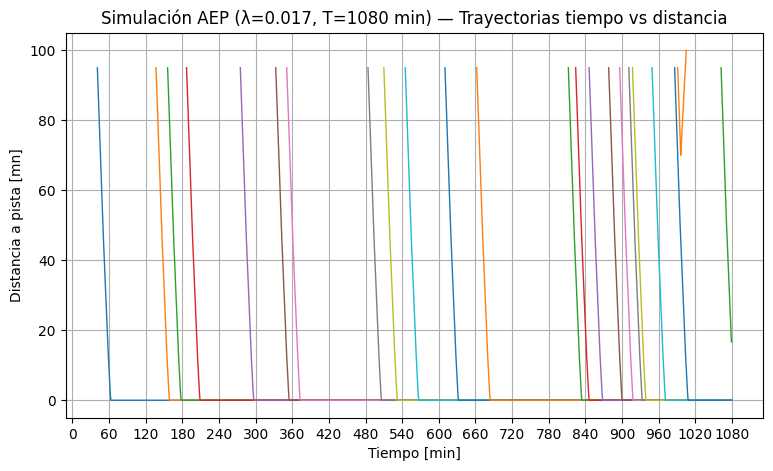

Resumen de la corrida:
- spawned: 23
- landed: 21
- diverted: 1
- still_backtracking: 0
- still_approach: 1


In [44]:
def run_and_plot(lam: float = 0.017, T_minutes: int = 1080):
    sim = AEPSimulator(lam=lam, T_minutes=T_minutes)
    summary = sim.run()

    # Visualización: tiempo vs distancia (una línea por avión)
    plt.figure(figsize=(9, 5))
    for p in sim.planes:
        t_arr = np.array(p.path_t)
        d_arr = np.array(p.path_d)
        mask = (d_arr >= 0.0) & (d_arr <= RADAR_NM + 1e-6)
        if mask.any():
            plt.plot(t_arr[mask], d_arr[mask], linewidth=1)
    plt.title(f"Simulación AEP (λ={lam}, T={T_minutes} min) — Trayectorias tiempo vs distancia")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Distancia a pista [mn]")
    plt.grid(True)
    import matplotlib.ticker as ticker
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(60))
    plt.show()

    print("Resumen de la corrida:")
    for k, v in summary.items():
        print(f"- {k}: {v}")
    return sim, summary

# Parámetros base de demo (podés cambiarlos y re-ejecutar)
_ = run_and_plot(lam=0.017, T_minutes=1080)



**Notas**
- Este punto 1 **no** incluye aún re-inserción en la cola tras backtrack (eso se agrega en los puntos 5–6).
- Para simular todo el día (6:00–00:00) usá `T_minutes = 1080`.
- La figura muestra cada avión como una **línea**: pendiente negativa → aproximación; pendiente positiva y salida del gráfico → desvío.

Punto 2

In [27]:
# Punto 2 - Calcular λ para 1 avión por hora
n_min = 60
avg_arrivals_per_hour = 1

lam = avg_arrivals_per_hour / n_min
print(f"λ = {lam:.6f} (≈ 1/60)")


λ = 0.016667 (≈ 1/60)


Punto 3

In [26]:
lam = 1/60          # probabilidad de arribo por minuto (1 avión/hora)
n_min = 60          # 1 hora = 60 minutos
reps = 200_000      # cantidad de horas simuladas
rng = np.random.default_rng(42)

# --- Simulación Monte Carlo ---
counts = rng.binomial(n=n_min, p=lam, size=reps)
hits = np.sum(counts == 5)
p_hat = hits / reps

# Error estándar e IC95% para la proporción
se = np.sqrt(p_hat * (1 - p_hat) / reps)
ci95 = (p_hat - 1.96*se, p_hat + 1.96*se)

print(f"Reps: {reps:,}")
print(f"Veces con 5 arribos: {hits:,}")
print(f"Estimación Monte Carlo P(N=5): {p_hat:.6f}")
print(f"SE: {se:.6f}  IC95%: ({ci95[0]:.6f}, {ci95[1]:.6f})")

# --- Comparación analítica (Binomial exacto) ---
p_exact = comb(n_min, 5) * (lam**5) * ((1-lam)**(n_min-5))
print(f"Probabilidad exacta (Binomial): {p_exact:.6f}")

Reps: 200,000
Veces con 5 arribos: 569
Estimación Monte Carlo P(N=5): 0.002845
SE: 0.000119  IC95%: (0.002612, 0.003078)
Probabilidad exacta (Binomial): 0.002787


# Punto 4 - Experimentos por distintos λ: congestión, atrasos y desvíos
## Ampliamos el simulador para medir congestión, atrasos vs. vuelo libre y desvíos.



=== λ = 0.02 ===
spawned: 21
landed: 18
diverted: 2
still_backtracking: 0
still_approach: 1


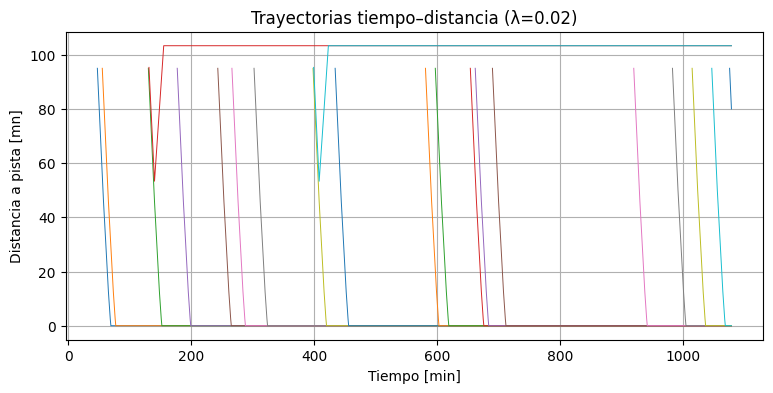


=== λ = 0.1 ===
spawned: 111
landed: 66
diverted: 44
still_backtracking: 0
still_approach: 1


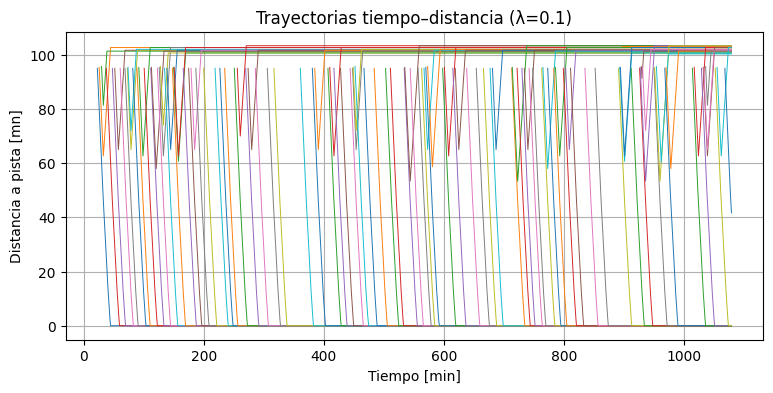


=== λ = 0.2 ===
spawned: 188
landed: 91
diverted: 93
still_backtracking: 2
still_approach: 2


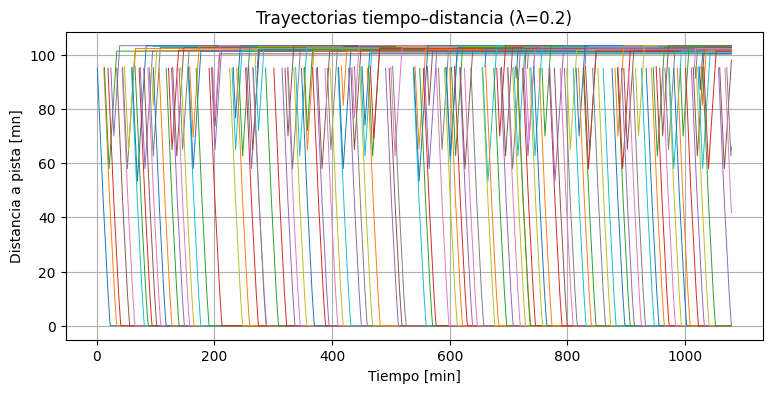


=== λ = 0.5 ===
spawned: 524
landed: 116
diverted: 403
still_backtracking: 1
still_approach: 4


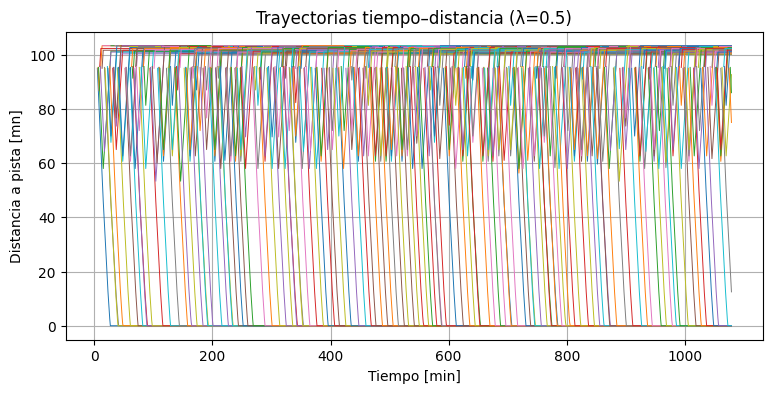


=== λ = 1.0 ===
spawned: 1080
landed: 211
diverted: 861
still_backtracking: 0
still_approach: 8


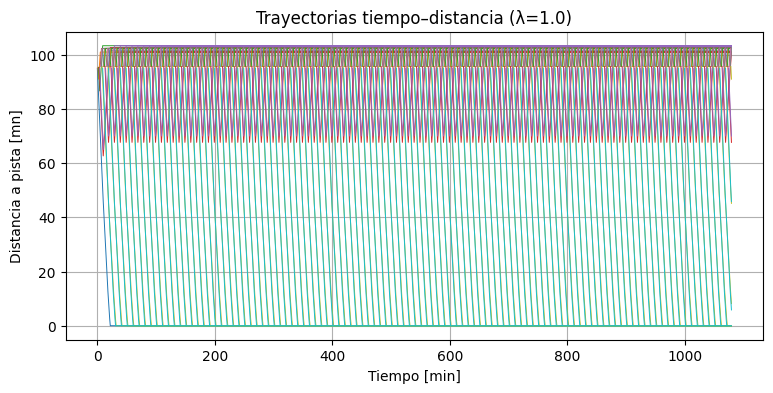

In [40]:

lam_list = [0.02, 0.1, 0.2, 0.5, 1.0]

for lam in lam_list:
    sim = AEPSimulator(lam=lam, T_minutes=1080)  # 18 horas
    summary = sim.run()
    print(f"\n=== λ = {lam} ===")
    for k, v in summary.items():
        print(f"{k}: {v}")

    # Gráfico de ejemplo
    import matplotlib.pyplot as plt
    import numpy as np
    plt.figure(figsize=(9,4))
    for p in sim.planes:
        t = np.array(p.path_t); d = np.array(p.path_d)
        if len(t)>0:
            plt.plot(t, d, lw=0.7)
    plt.title(f"Trayectorias tiempo–distancia (λ={lam})")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Distancia a pista [mn]")
    plt.grid(True)
    plt.show()


In [45]:


# 1) (Si no lo tenés) tiempo ideal de vuelo libre desde 100 mn
def _free_flight_minutes_from_100nm():
    NM_PER_MIN_FROM_KTS = 1.0/60.0
    segs = [
        (100-50, 300.0),  # 100→50 a 300 kts
        (50-15, 250.0),   # 50→15 a 250 kts
        (15-5, 200.0),    # 15→5 a 200 kts
        (5-0, 150.0),     # 5→0 a 150 kts
    ]
    t = 0.0
    for dist_nm, kts in segs:
        t += dist_nm / (kts * (1.0/60.0))
    return t

try:
    FREE_FLIGHT_MIN
except NameError:
    FREE_FLIGHT_MIN = _free_flight_minutes_from_100nm()


# 3) Helpers
def mean_se(values):
    arr = np.array(values, dtype=float)
    m = float(arr.mean()) if arr.size else float("nan")
    se = float(arr.std(ddof=1)/np.sqrt(arr.size)) if arr.size > 1 else float("nan")
    return m, se

def summarize_sim(sim):
    """Lee sim.planes y computa métricas necesarias."""
    planes = getattr(sim, "planes", [])
    spawned = len(planes)
    landed = [p for p in planes if getattr(p, "state", None) == "landed"]
    diverted = sum(1 for p in planes if getattr(p, "state", None) == "diverted")

    # congestión (si agregaste congested_any)
    if planes and hasattr(planes[0], "congested_any"):
        congested = sum(1 for p in planes if getattr(p, "congested_any", False))
        congest_rate = congested / spawned if spawned else float("nan")
    else:
        congest_rate = float("nan")  # si no marcás congestión, queda NaN

    # atraso (en minutos) vs vuelo libre
    delays = []
    for p in landed:
        t_spawn = getattr(p, "t_spawn", getattr(p, "entry_min", None))
        if t_spawn is not None and p.landed_at is not None:
            delay = p.landed_at - (t_spawn + FREE_FLIGHT_MIN)
            if delay < 0: delay = 0.0
            delays.append(delay)
    avg_delay_min = float(np.mean(delays)) if delays else 0.0

    divert_rate = diverted / spawned if spawned else float("nan")
    return {
        "spawned": spawned,
        "landed": len(landed),
        "divert_rate": divert_rate,
        "congest_rate": congest_rate,
        "avg_delay_min": avg_delay_min,
    }

def evaluate_lambda(lam, reps=50, T_minutes=1080, show_example_plot=False):
    """Corre varias simulaciones y reporta media ± SE de las métricas."""
    divert_rates, congest_rates, delays = [], [], []
    landed_list, spawned_list = [], []

    for _ in range(reps):
        sim = AEPSimulator(lam=lam, T_minutes=T_minutes)
        _ = sim.run()
        m = summarize_sim(sim)
        spawned_list.append(m["spawned"])
        landed_list.append(m["landed"])
        divert_rates.append(m["divert_rate"])
        congest_rates.append(m["congest_rate"])
        delays.append(m["avg_delay_min"])

    sm, _  = mean_se(spawned_list)
    lm, _  = mean_se(landed_list)
    drm, drse = mean_se(divert_rates)
    cgm, cgse = mean_se(congest_rates)
    adm, adse = mean_se(delays)

    print(f"\nλ={lam} | reps={reps} | T={T_minutes} min")
    print(f"- Spawned promedio: {sm:.1f}   Landed promedio: {lm:.1f}")
    print(f"- Congestión: {cgm:.3f} ± {cgse:.003f} (fracción de aviones)")
    print(f"- Atraso promedio: {adm:.3f} ± {adse:.003f} min")
    print(f"- Desvío a Montevideo: {drm:.3f} ± {drse:.003f} (fracción)")

    if show_example_plot:
        # una corrida de ejemplo para ver las trayectorias
        sim = AEPSimulator(lam=lam, T_minutes=360)
        _ = sim.run()
        plt.figure(figsize=(9,4))
        for p in sim.planes:
            t = np.array(getattr(p, "path_t", []))
            d = np.array(getattr(p, "path_d", []))
            if t.size and d.size:
                plt.plot(t, d, lw=0.7)
        plt.title(f"Trayectorias tiempo–distancia (ejemplo, λ={lam})")
        plt.xlabel("Tiempo [min]"); plt.ylabel("Distancia a pista [mn]")
        plt.grid(True); plt.show()

# 4) Ejecutá para los λ pedidos
for lam in [0.02, 0.1, 0.2, 0.5, 1.0]:
    evaluate_lambda(lam, reps=60, T_minutes=1080, show_example_plot=False)



λ=0.02 | reps=60 | T=1080 min
- Spawned promedio: 21.7   Landed promedio: 19.5
- Congestión: 0.050 ± 0.007 (fracción de aviones)
- Atraso promedio: 0.000 ± 0.000 min
- Desvío a Montevideo: 0.076 ± 0.008 (fracción)

λ=0.1 | reps=60 | T=1080 min
- Spawned promedio: 106.5   Landed promedio: 67.6
- Congestión: 0.273 ± 0.006 (fracción de aviones)
- Atraso promedio: 0.008 ± 0.002 min
- Desvío a Montevideo: 0.344 ± 0.005 (fracción)

λ=0.2 | reps=60 | T=1080 min
- Spawned promedio: 217.4   Landed promedio: 95.2
- Congestión: 0.453 ± 0.004 (fracción de aviones)
- Atraso promedio: 0.032 ± 0.003 min
- Desvío a Montevideo: 0.546 ± 0.003 (fracción)

λ=0.5 | reps=60 | T=1080 min
- Spawned promedio: 538.2   Landed promedio: 128.6
- Congestión: 0.554 ± 0.002 (fracción de aviones)
- Atraso promedio: 0.140 ± 0.004 min
- Desvío a Montevideo: 0.750 ± 0.001 (fracción)

λ=1.0 | reps=60 | T=1080 min
- Spawned promedio: 1080.0   Landed promedio: 211.0
- Congestión: 0.799 ± 0.000 (fracción de aviones)
- Atras